<a href="https://colab.research.google.com/github/MatiasMoreno707/lab05-lp/blob/dev/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### SEMANA 5: MODELOS DE APRENDIZAJE AUTOMÁTICO. MODELOS DE APRENDIZAJE PROFUNDO

#### a. Por medio de la librería ‘Pandas’, lea la base de datos, separe las variables numéricas de las no numéricas tomando en cuenta la información que se encuentra en el repositorio, calcule sus estadísticos descriptivos y halle la matriz de correlación.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'

columnas = [
    "Sample_code_number", "Clump_Thickness", "Uniformity_Cell_Size", "Uniformity_Cell_Shape",
    "Marginal_Adhesion", "Single_Epithelial_Cell_Size", "Bare_Nuclei",
    "Bland_Chromatin", "Normal_Nucleoli", "Mitoses", "Class"
]

In [ ]:
df = pd.read_csv(url, names=columnas)
df.head()

,Sample_code_number,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [ ]:
# tamaño del dataframe
df.shape


(699, 11)

In [ ]:
# tipos de datos
df.dtypes

,0
Sample_code_number,int64
Clump_Thickness,int64
Uniformity_Cell_Size,int64
Uniformity_Cell_Shape,int64
Marginal_Adhesion,int64
Single_Epithelial_Cell_Size,int64
Bare_Nuclei,object
Bland_Chromatin,int64
Normal_Nucleoli,int64
Mitoses,int64


In [ ]:
# Eliminamos esta variable al no ser necesaria para el analisis
df.drop("Sample_code_number", axis=1, inplace=True)
df.head()

,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


In [ ]:
# no hay datos faltantes
df.isnull().sum()

,0
Clump_Thickness,0
Uniformity_Cell_Size,0
Uniformity_Cell_Shape,0
Marginal_Adhesion,0
Single_Epithelial_Cell_Size,0
Bare_Nuclei,0
Bland_Chromatin,0
Normal_Nucleoli,0
Mitoses,0
Class,0


In [ ]:
# hay un dato ? que tenemos que manejarlo
df.value_counts("Bare_Nuclei")

,count
Bare_Nuclei,
1,402
10,132
2,30
5,30
3,28
8,21
4,19
?,16
9,9


In [42]:
# Reemplazamos el ? por la mediana
df["Bare_Nuclei"] = df["Bare_Nuclei"].replace("?", np.nan).astype(float)
df["Bare_Nuclei"] = df["Bare_Nuclei"].fillna(df["Bare_Nuclei"].median())


In [45]:
# Obtenemos datos descriptivos de cada variable
df.describe()

,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.486409,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.621929,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


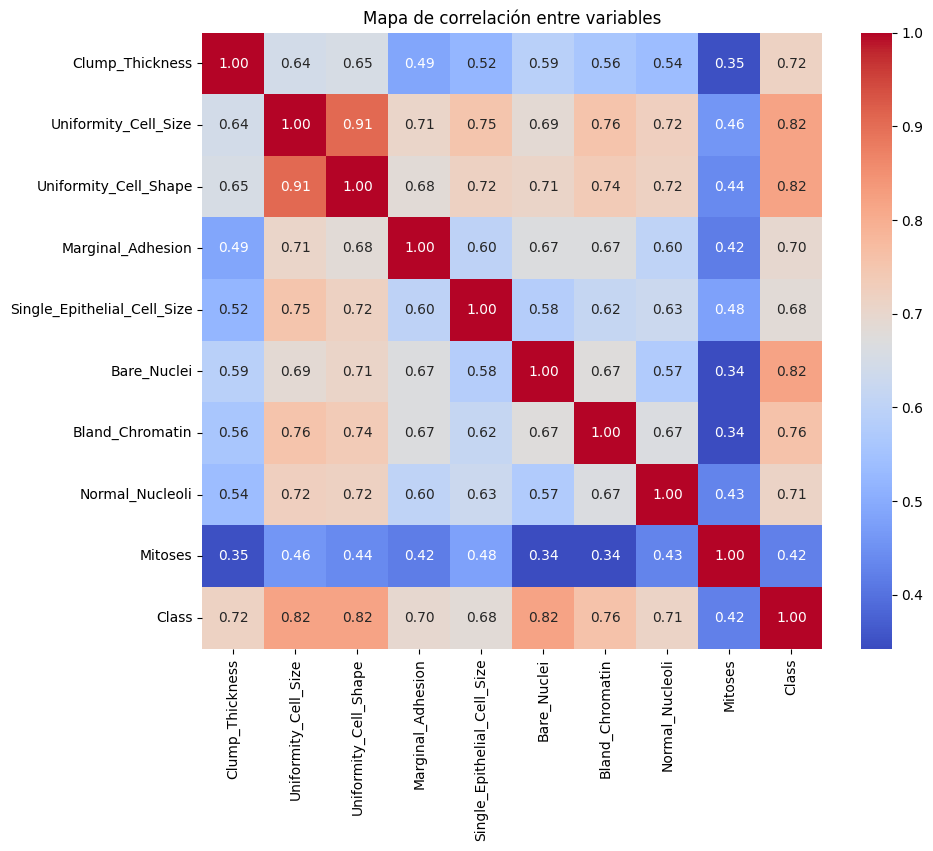

In [44]:
# Vemos las correlaciones entre las variable, donde se vea de que hay variables que tienen
# correlacion alta como la de Uniformity_Cell_Size con Uniformity_Cell_Shape
plt.figure(figsize=(10, 8))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de correlación entre variables")
plt.show()

#### b. Por medio de la librería ‘Matplotlib’, elabore histogramas, gráficos de densidad, box plot y diagramas de dispersión incluyendo diversos parámetros para estos.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

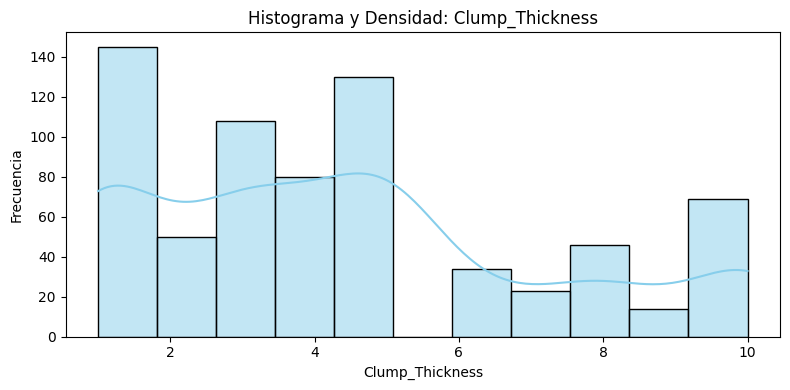

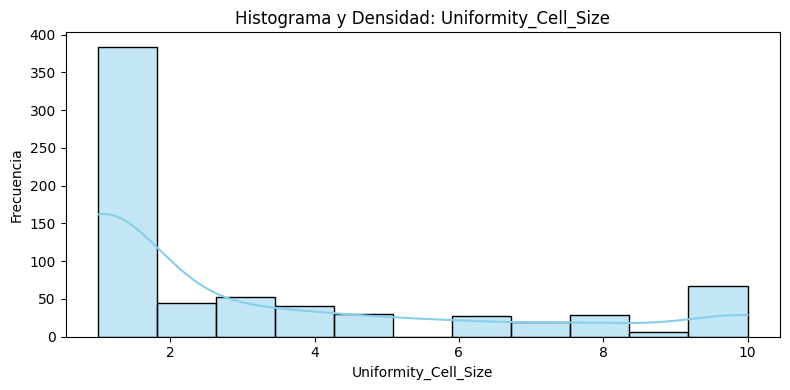

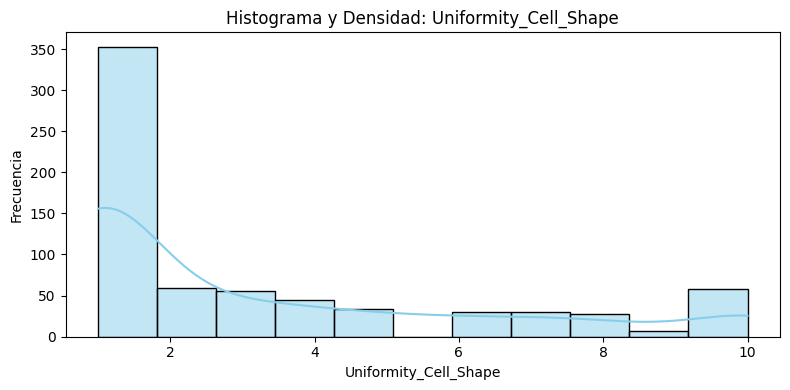

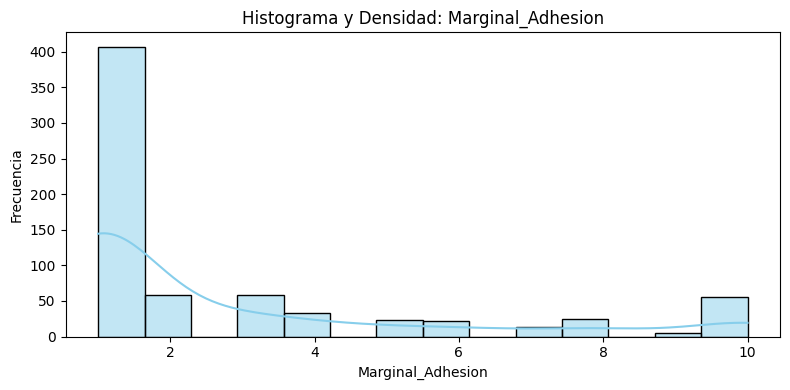

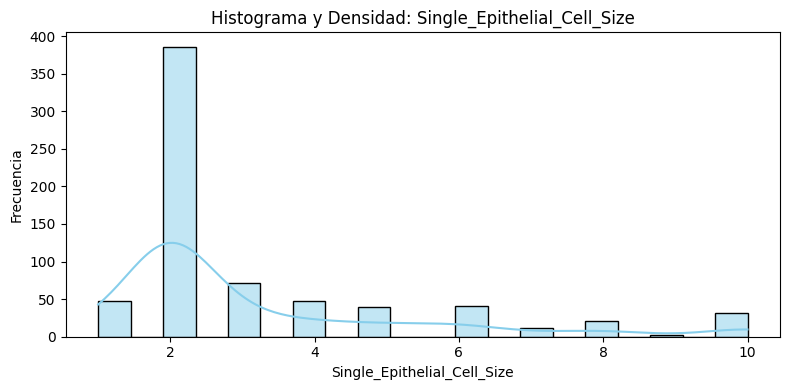

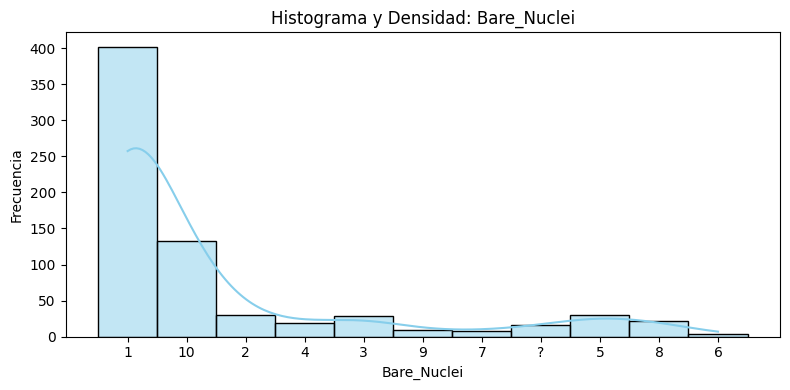

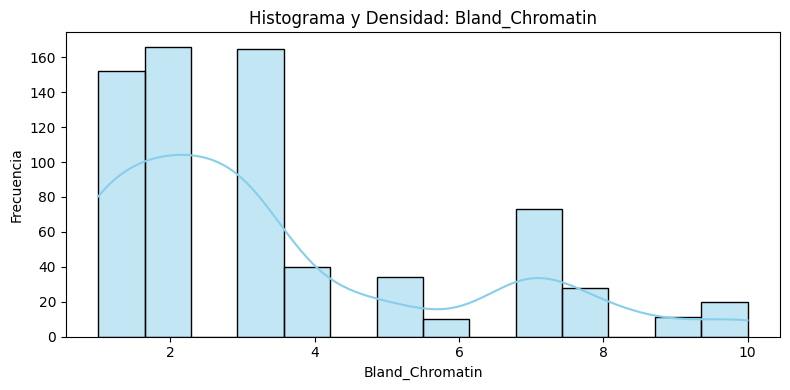

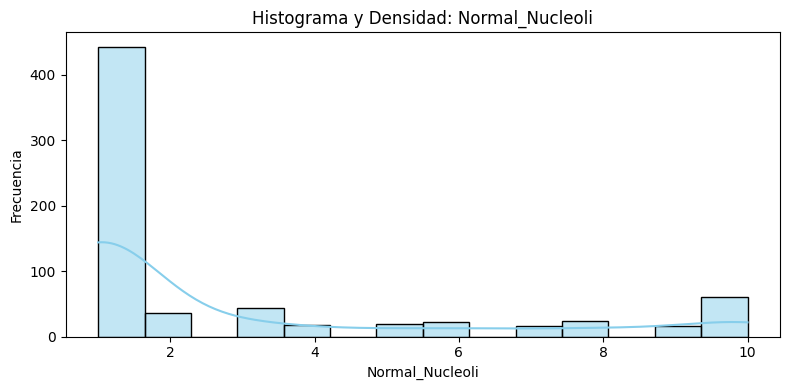

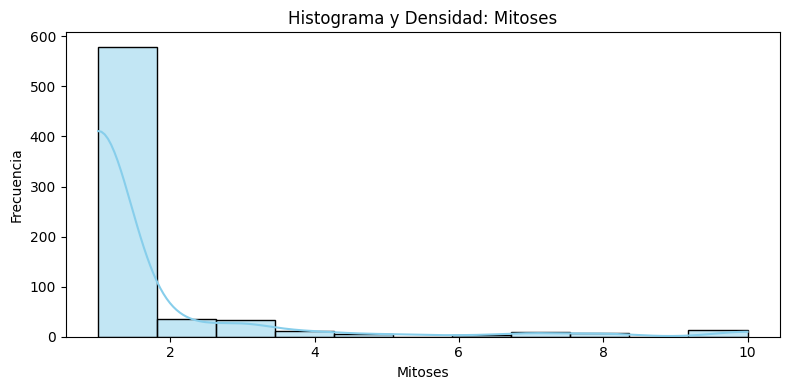

In [ ]:
# Graficamos los histogramas por variable para ver la frecuencia de los datos
for col in df.columns[:-1]:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Histograma y Densidad: {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

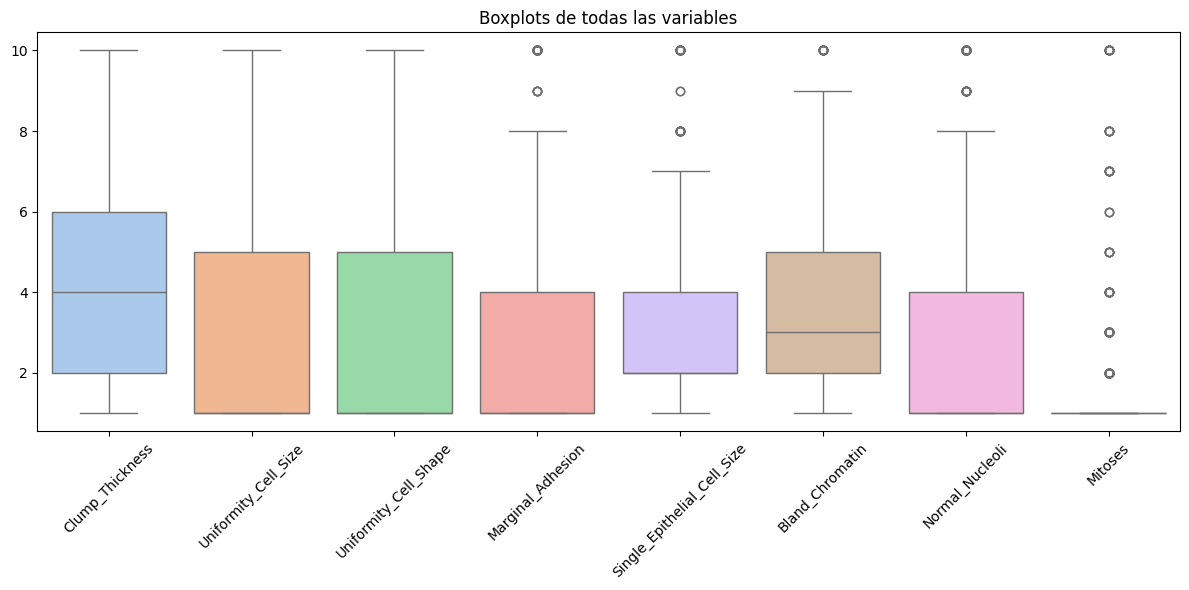

In [ ]:
# En el grafico nos muestra la dispersion de los datos y algunos outliers por variable
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop("Class", axis=1), palette="pastel")
plt.title("Boxplots de todas las variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

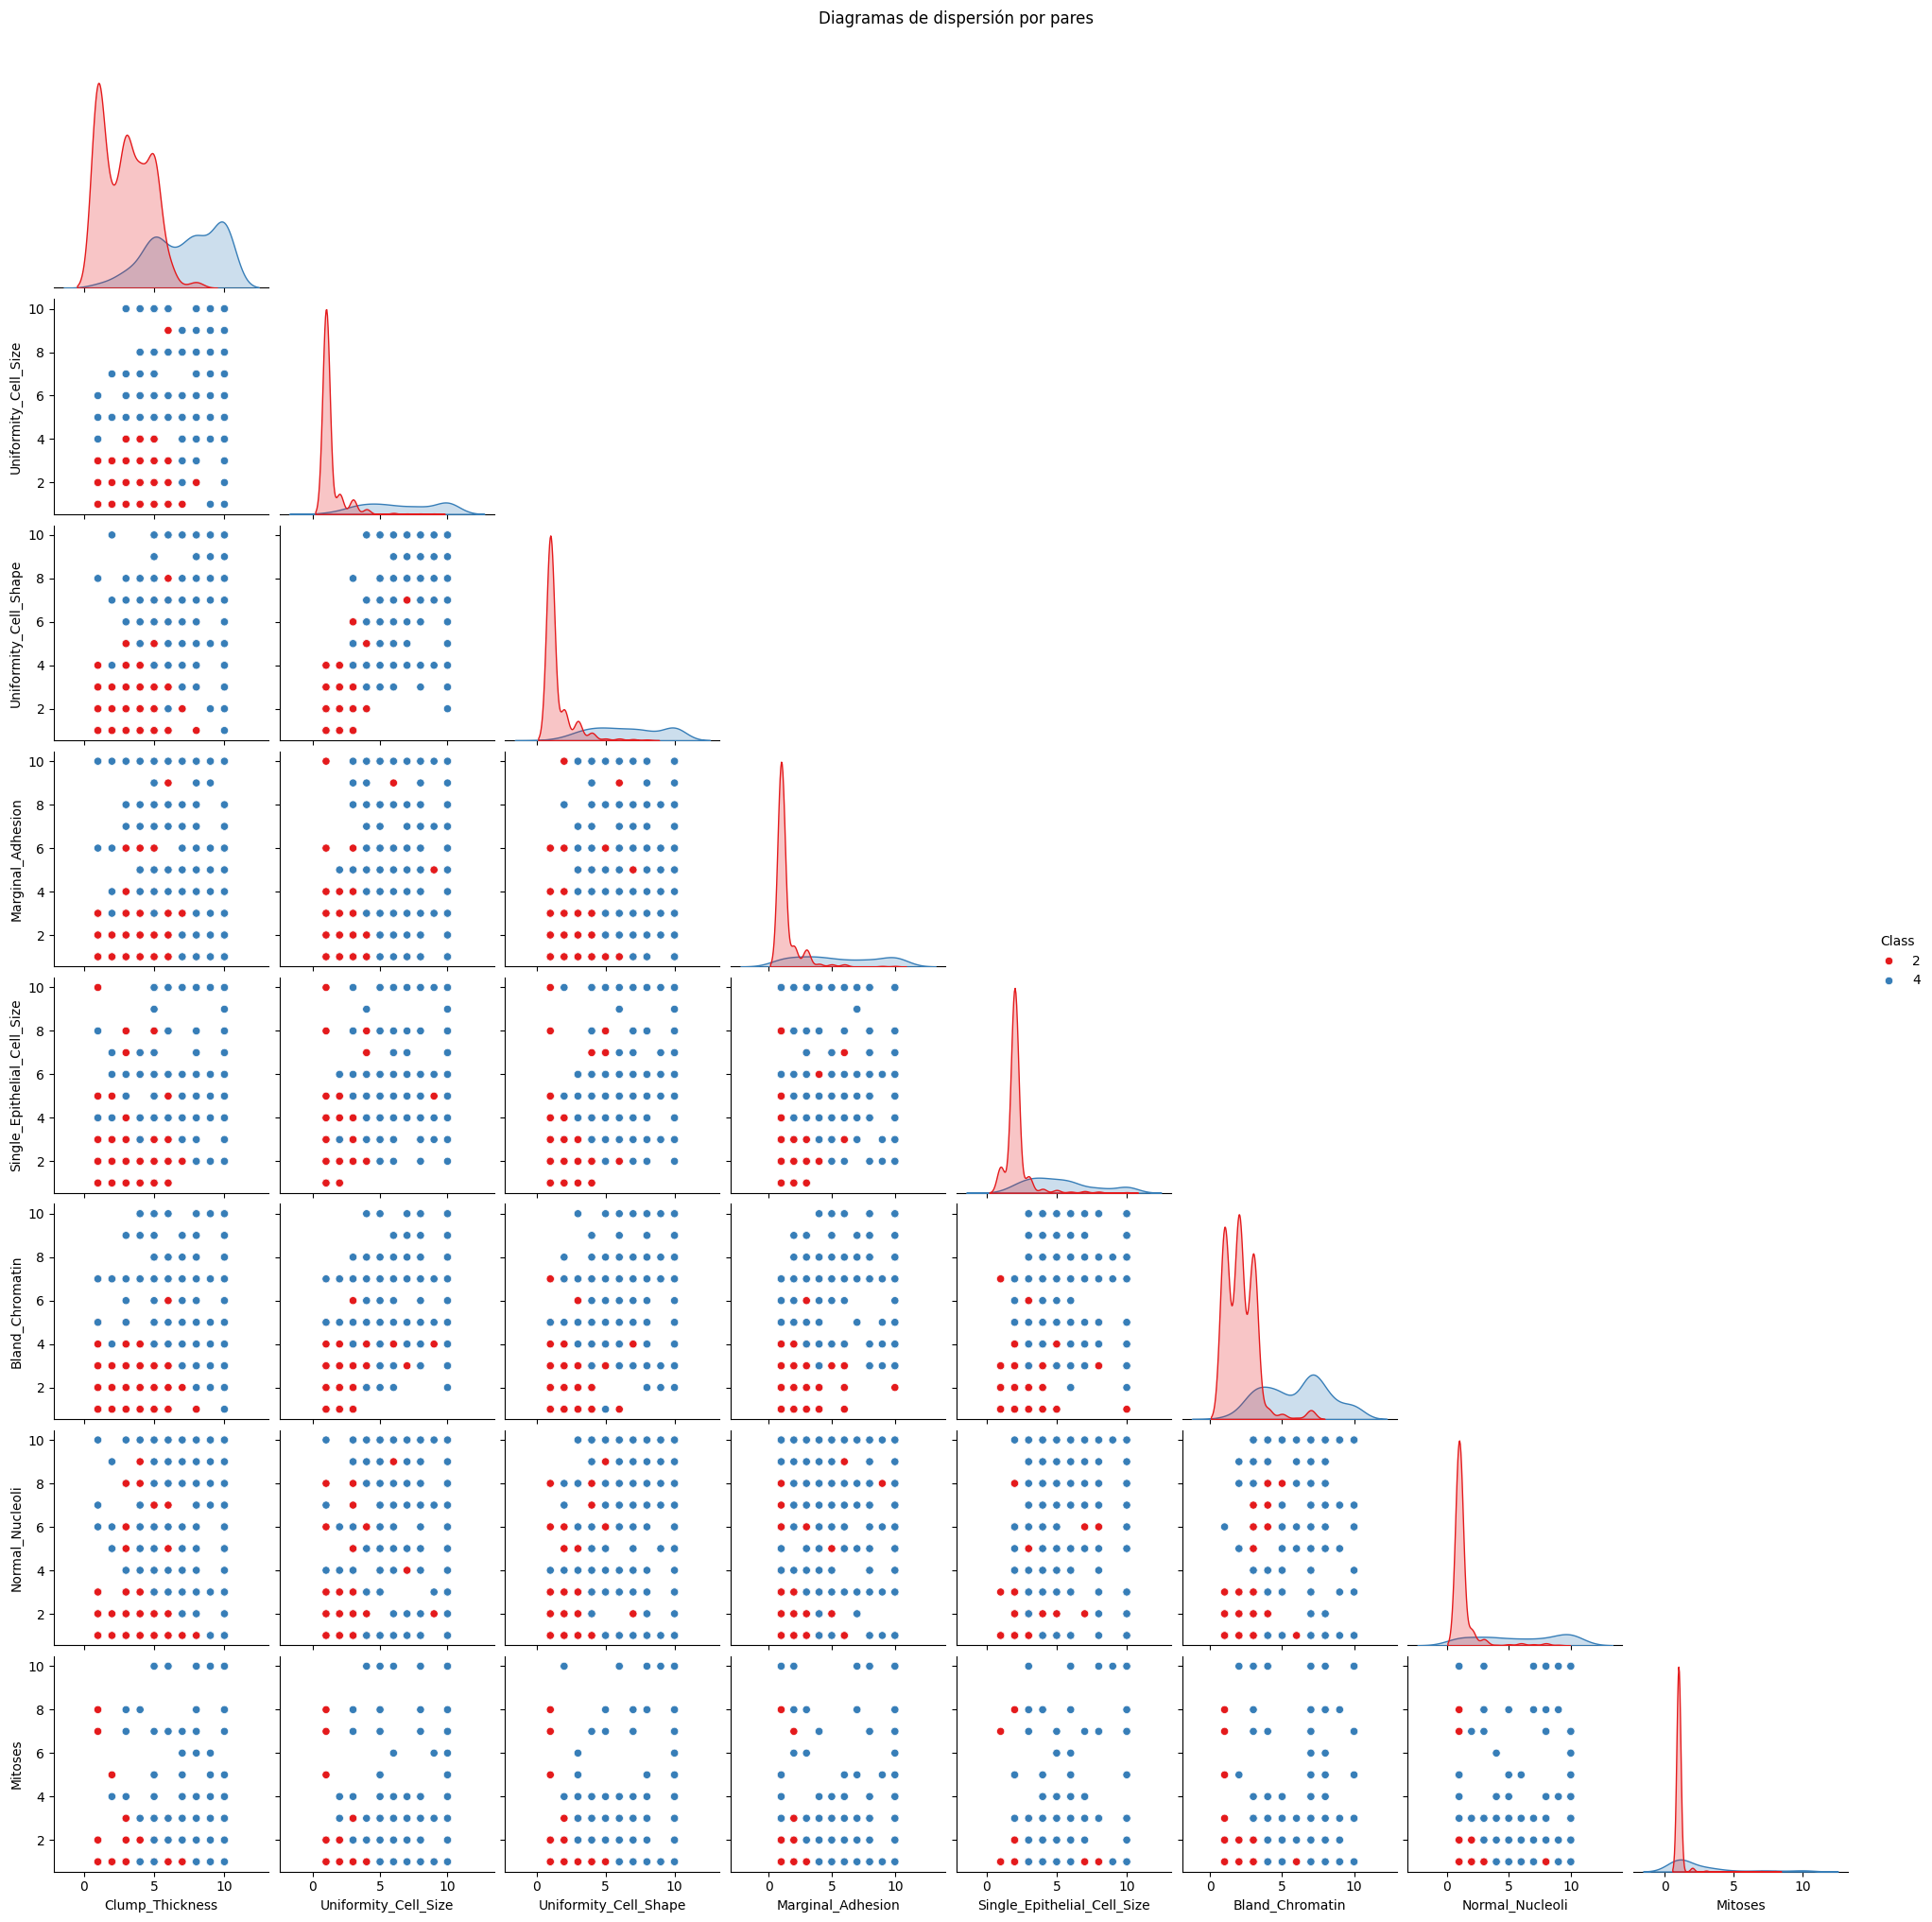

In [ ]:
# Mostramos los diagramas de dispersión para ver las relaciones entre variables
sns.pairplot(df, hue="Class", palette="Set1", corner=True)
plt.suptitle("Diagramas de dispersión por pares", y=1.02)
plt.show()

#### a. Utilice la librería ‘Scikit-learn’ para separar la información en datos de entrenamiento y prueba. Además, implemente un modelo k-NN con dicha información, realice pronósticos y mida la precisión para los datos de entrenamiento y prueba.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [47]:
X = df.drop("Class", axis=1)  # Variables independientes
y = df["Class"]               # Variable dependiente

In [48]:
# Separamo nuestros datos de entrenamiento y pruebas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [49]:
# Creamos y entrenamos nuestro de modelo
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [50]:
# Realizamos predicciones
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

In [51]:
# Medimos la precision de nuestro modelo
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f"Precisión en entrenamiento: {acc_train:.2f}")
print(f"Precisión en prueba: {acc_test:.2f}")

Precisión en entrenamiento: 0.97
Precisión en prueba: 0.98
